In [1]:
import pandas as pd


In [2]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print(train.shape)
print(test.shape)
train.head()

(577347, 12)
(247435, 11)


,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY


In [3]:
print(train['class'].value_counts())
print("\n")
print(train.isnull().sum())
print("\n")
print(train.dtypes)
print("\n")
print(train.describe())

class
GALAXY    377480
QSO       117143
STAR       82724
Name: count, dtype: int64


id                   0
alpha                0
delta                0
u                    0
g                    0
r                    0
i                    0
z                    0
redshift             0
spectral_type        0
galaxy_population    0
class                0
dtype: int64


id                     int64
alpha                float64
delta                float64
u                    float64
g                    float64
r                    float64
i                    float64
z                    float64
redshift             float64
spectral_type         object
galaxy_population     object
class                 object
dtype: object


                 id          alpha          delta              u  \
count  577347.00000  577347.000000  577347.000000  577347.000000   
mean   288673.00000     181.616673      21.834654      22.441926   
std    166665.86727      96.242941      18.933570       

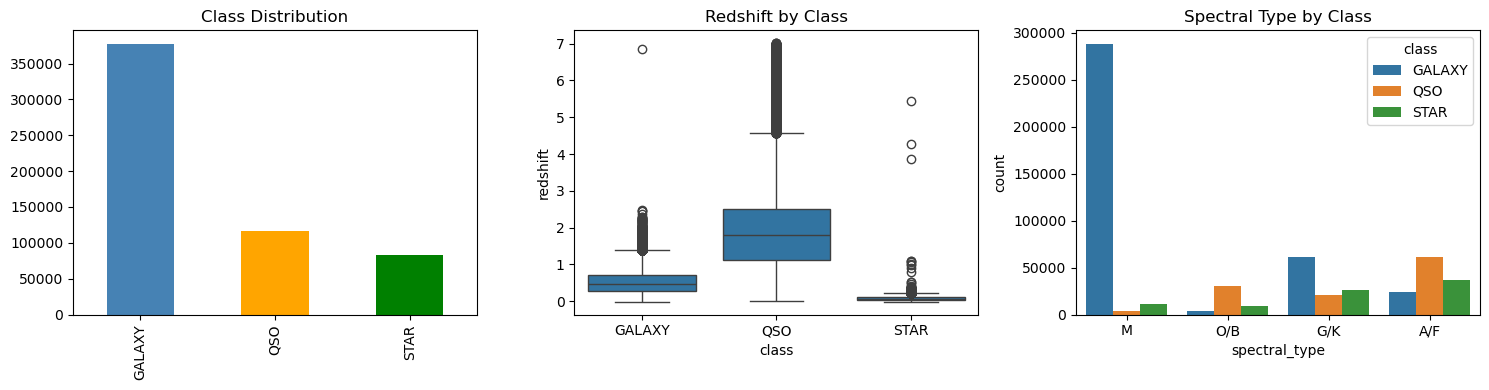

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Class distribution
train['class'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue','orange','green'])
axes[0].set_title('Class Distribution')
axes[0].set_xlabel('')

# Redshift by class
sns.boxplot(data=train, x='class', y='redshift', ax=axes[1])
axes[1].set_title('Redshift by Class')

# Spectral type by class
sns.countplot(data=train, x='spectral_type', hue='class', ax=axes[2])
axes[2].set_title('Spectral Type by Class')

plt.tight_layout()
plt.show()

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score

# Encode categoricals
le_spectral = LabelEncoder()
le_galaxy = LabelEncoder()
le_target = LabelEncoder()

train['spectral_type_enc'] = le_spectral.fit_transform(train['spectral_type'])
train['galaxy_population_enc'] = le_galaxy.fit_transform(train['galaxy_population'])

# Features and target
features = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift', 
            'spectral_type_enc', 'galaxy_population_enc']

X = train[features]
y = le_target.fit_transform(train['class'])

# Split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Baseline model
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Evaluate
y_pred = rf.predict(X_val)
print(f"Accuracy: {accuracy_score(y_val, y_pred):.4f}")
print(classification_report(y_val, y_pred, target_names=le_target.classes_))

Accuracy: 0.9603
              precision    recall  f1-score   support

      GALAXY       0.97      0.97      0.97     75496
         QSO       0.96      0.96      0.96     23429
        STAR       0.91      0.90      0.90     16545

    accuracy                           0.96    115470
   macro avg       0.95      0.94      0.95    115470
weighted avg       0.96      0.96      0.96    115470



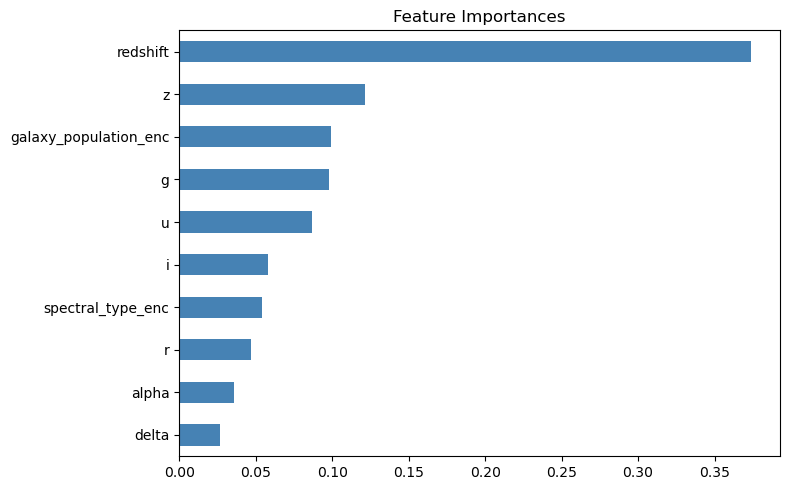

In [7]:


importances = pd.Series(rf.feature_importances_, index=features)
importances.sort_values().plot(kind='barh', figsize=(8, 5), color='steelblue')
plt.title('Feature Importances')
plt.tight_layout()
plt.show()

In [8]:
# Feature engineering - colour indices
train['u_g'] = train['u'] - train['g']
train['g_r'] = train['g'] - train['r']
train['r_i'] = train['r'] - train['i']
train['i_z'] = train['i'] - train['z']

# Do same for test
test['spectral_type_enc'] = le_spectral.transform(test['spectral_type'])
test['galaxy_population_enc'] = le_galaxy.transform(test['galaxy_population'])
test['u_g'] = test['u'] - test['g']
test['g_r'] = test['g'] - test['r']
test['r_i'] = test['r'] - test['i']
test['i_z'] = test['i'] - test['z']

print("New features added!")
print(train.shape)

New features added!
(577347, 18)


In [9]:

# Updated feature list with colour indices
features_v2 = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift', 
                'spectral_type_enc', 'galaxy_population_enc',
                'u_g', 'g_r', 'r_i', 'i_z']

X_v2 = train[features_v2]
y_v2 = le_target.transform(train['class'])

# Split
X_train_v2, X_val_v2, y_train_v2, y_val_v2 = train_test_split(
    X_v2, y_v2, test_size=0.2, random_state=42, stratify=y_v2)

# Retrain
rf_v2 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_v2.fit(X_train_v2, y_train_v2)

# Evaluate
y_pred_v2 = rf_v2.predict(X_val_v2)
print(f"Baseline Accuracy: 0.9603")
print(f"New Accuracy:      {accuracy_score(y_val_v2, y_pred_v2):.4f}")
print()
print(classification_report(y_val_v2, y_pred_v2, target_names=le_target.classes_))

Baseline Accuracy: 0.9603
New Accuracy:      0.9594

              precision    recall  f1-score   support

      GALAXY       0.97      0.97      0.97     75496
         QSO       0.96      0.96      0.96     23429
        STAR       0.91      0.89      0.90     16545

    accuracy                           0.96    115470
   macro avg       0.95      0.94      0.94    115470
weighted avg       0.96      0.96      0.96    115470

